# 05: Fixed-path Neural ODE loss comparison

**Status, 27 August:** Fourier adequacy and fixed-path implementation checks passed. Ten thousand updates are now fixed as a common finite compute budget. Existing late-window ratios show that this budget does not establish numerical convergence, so comparisons include learning histories and are interpreted as finite-budget behaviour. Signature value and gradient audit is next. Detailed procedure: `../docs/neural_ode_operator_experiments.md` §§1 to 3. Bibliographic entries: `../papers/references.bib`.

## Experiment

This notebook asks how training loss changes a learned path when one model cannot reproduce every target feature perfectly. It begins with familiar pointwise and integral losses, then introduces signature losses that compare ordered path structure. Sections 7 to 10 fix evaluation, justify settings and record current status.

One target path is fitted repeatedly. Model class, initialization, solver, observations, optimizer and update count remain fixed; training loss changes. Any systematic difference between fitted paths can therefore be attributed to the loss, subject to optimization variability checked across paired seeds.

Target $Y^\star:[0,1]\to\mathbb R^2$ is

$$
Y_1^\star(t)=\cos(2\pi t)+a(t)\cos(12\pi t),\qquad
Y_2^\star(t)=\sin(2\pi t)+a(t)\sin(12\pi t),
$$

where $a(t)=0.3\exp[-100(t-0.25)^2]$. Large loop gives global structure; oscillatory burst near $t=0.25$ gives local structure.

Fitted path is generated by

$$
h(0)=\eta,\qquad
\dot h(t)=f_\theta(\gamma(t),h(t)),\qquad
\widehat Y(t)=g_\phi(h(t)).
$$

Parameter vector $\Theta=(\eta,\theta,\phi)$ contains learned initial state $\eta\in\mathbb R^H$, two-layer tanh vector field $f_\theta$ and affine decoder $g_\phi:\mathbb R^H\to\mathbb R^2$. Solving differential equation produces hidden trajectory $h(t)$; decoder turns it into fitted path $\widehat Y(t)$. This Neural ODE construction follows Chen et al. (2018). Time enters through Fourier features

$$
\gamma(t)=\left[t,\sin(2^k\pi t),\cos(2^k\pi t)\right]_{k=0}^{K-1},\qquad K=5,
$$

following Tancik et al. (2020): periodic features help neural networks represent high-frequency variation. Fixed-step RK4 uses step $1/512$, matching evaluation grid. Section 10 verifies that these features let expressive model reproduce target accurately.

Reference losses are sample MSE and elapsed-time $J_2$. Global and local signature losses are next, after their value and gradient audit. Smooth-only $H^1$ remains secondary.


## Execution stages

Adequacy has passed. Remaining runs are staged as follows:

1. retain 10,000 updates as common finite compute budget;
2. run signature value and gradient audit with provisional unit output scaling;
3. run seed-zero uniform pilot for MSE, $J_2$, global signature and local signature losses in both capacities;
4. compare common evaluation metrics through training and at update 10,000;
5. extend across paired seeds only after signature optimization is numerically usable.

Reusable code lives in `../src/pathloss/fixed_path.py` and `../src/pathloss/signatures.py`. Launch commands are in `../README.md`. Cells below inspect target, stored runs and cross-metrics.


### Budget diagnostic fixed on 26 August

Seed-zero pilot shows decreasing losses near update 5,000. Expressive clustered pair is selected because expressive capacity should approach same exact target under MSE and $J_2$, while this pair currently has largest dense-error separation. Diagnostic repeats only this pair from identical initialization for 10,000 updates. Model, clustered observations, solver, Adam learning rate and all loss definitions remain fixed.

For positive training losses $\ell_k$, define late-window ratio

$$
R=\frac{\operatorname{median}\{\ell_k:9500\leq k<10000\}}{\operatorname{median}\{\ell_k:9000\leq k<9500\}}.
$$

Loss remains materially decreasing when $R<0.95$: last 500 updates reduce median objective by more than 5% relative to preceding 500. Threshold is an engineering stopping rule fixed before diagnostic. Initial fingerprints must match across losses. Training loss at update 4,999 is compared with existing pilot to check that ARC run reproduces trajectory through original budget; failure requires a matched 5,000-update ARC run before cross-budget comparison.

Outcome meanings are fixed before run:

| outcome | action |
|---|---|
| either $R<0.95$ | 10,000 updates remain inadequate; extend diagnostic before seed sweep |
| both $R\geq0.95$ and MSE--$J_2$ dense gap shrinks | 5,000-update result contains optimization-speed effect; use accepted longer budget for every paired fit |
| both $R\geq0.95$ and dense gap persists | discrepancy effect survives budget check; freeze budget and proceed across seeds |

Representative saved models are reevaluated with RK4 step $1/1024$ before interpreting small metric differences. Material change requires finer training solver.

#### Result, 27 August

Both runs have identical initial-state fingerprints. Late-window calculation gives

| training loss | median, updates 9,000 to 9,499 | median, updates 9,500 to 9,999 | $R$ | dense MSE | $H^1$ | $L^\infty$ | local $J_2$ |
|---|---:|---:|---:|---:|---:|---:|---:|
| MSE | $1.006\times10^{-5}$ | $6.563\times10^{-6}$ | $0.653$ | $1.152\times10^{-4}$ | $1.242\times10^{-2}$ | $4.346\times10^{-2}$ | $4.422\times10^{-4}$ |
| $J_2$ | $1.165\times10^{-6}$ | $1.025\times10^{-6}$ | $0.880$ | $5.597\times10^{-5}$ | $7.086\times10^{-3}$ | $3.142\times10^{-2}$ | $2.085\times10^{-4}$ |

Both $R$ values are below $0.95$, so 10,000 updates fail fixed stopping rule. Saved paths place largest residuals inside oscillatory event interval; current $J_2$ fit has lower error there and under every reported dense metric. This difference is not evidence of a converged loss-specific optimum while both objectives remain materially decreasing.

Local 5,000-update pilots and ARC trajectory begin from same fingerprints but diverge numerically during optimization. Cross-budget metric changes are therefore descriptive only. Stopping conclusion uses two late windows from each single ARC history and does not depend on cross-platform comparison.

#### Finite-budget decision, 27 August

Ten thousand updates are adopted as a common compute horizon rather than a convergence threshold. This changes experiment question from comparison of converged optima to comparison of what each loss learns under equal optimization effort. The late-window result remains useful: it prevents terminal differences from being described as converged loss geometry. Common evaluation metrics at fixed checkpoints are used because raw training objectives have different scales.

Next cell reproduces stopping calculation directly from saved ARC histories. Window values, ratio and pass/fail column are computed rather than copied from table above.


In [1]:
from pathlib import Path
import json
import statistics
import pandas as pd

budget_root = Path('../results/runs/neural_ode_fixed_path_budget_10k')
rows = []
fingerprints = []
for loss in ['mse', 'j2']:
    run = budget_root / 'expressive' / 'seed0' / 'clustered' / loss
    history = json.loads((run / 'history.json').read_text())
    values = [row['train_loss'] for row in history]
    median_9000_9499 = statistics.median(values[9000:9500])
    median_9500_9999 = statistics.median(values[9500:10000])
    R = median_9500_9999 / median_9000_9499
    meta = json.loads((run / 'meta.json').read_text())
    fingerprints.append(meta['initial_fingerprint'])
    rows.append({
        'loss': loss,
        'median loss, updates 9000:9499': median_9000_9499,
        'median loss, updates 9500:9999': median_9500_9999,
        'R': R,
        'R >= 0.95': R >= 0.95,
    })

assert len(set(fingerprints)) == 1, 'paired runs did not share initialization'
pd.DataFrame(rows).set_index('loss')


,"median loss, updates 9000:9499","median loss, updates 9500:9999",R,R >= 0.95
loss,,,,
mse,0.000010,0.000007,0.652538,False
j2,0.000001,0.000001,0.879770,False


## 0. Target and observation design

First panel shows path to be fitted. Second shows where 64 training values are supplied under two observation conditions. Clustered condition places fewer observations around oscillatory event $[0.15,0.35]$.


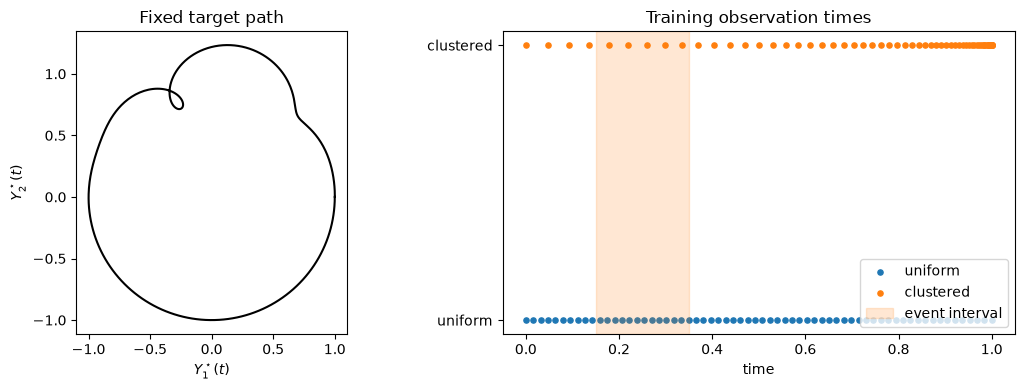

In [2]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import torch

REPO_ROOT = Path('..').resolve()
if str(REPO_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / 'src'))

from pathloss.fixed_path import fixed_target, observation_times

t_fine = torch.linspace(0.0, 1.0, 513)
target_fine = fixed_target(t_fine)
uniform_times = observation_times(64, 'uniform')
clustered_times = observation_times(64, 'clustered')

figure, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(target_fine[:, 0], target_fine[:, 1], color='black')
axes[0].set_title('Fixed target path')
axes[0].set_aspect('equal')
axes[0].set_xlabel(r'$Y_1^\star(t)$')
axes[0].set_ylabel(r'$Y_2^\star(t)$')
axes[1].scatter(uniform_times, torch.zeros_like(uniform_times), s=14, label='uniform')
axes[1].scatter(clustered_times, torch.ones_like(clustered_times), s=14, label='clustered')
axes[1].axvspan(0.15, 0.35, color='tab:orange', alpha=0.18, label='event interval')
axes[1].set_yticks([0, 1], ['uniform', 'clustered'])
axes[1].set_xlabel('time')
axes[1].set_title('Training observation times')
axes[1].legend(loc='lower right')
figure.tight_layout()


## 1. Loss comparison principle

Training selects parameters making fitted path close to target under one loss. Since losses define closeness differently, they can prefer different approximations when model capacity is limited.

Let $0=t_0<\cdots<t_{C-1}=T$ be training observation times, $Y_r=Y^\star(t_r)\in\mathbb R^{d_Y}$ with $d_Y=2$, and $\widehat Y_r=\widehat Y_\Theta(t_r)$. Residual is $e_r=\widehat Y_r-Y_r$. For discrepancy $D$, fitted parameters are

$$
\widehat\Theta_D=\operatorname*{arg\,min}_\Theta D(\widehat Y_\Theta,Y^\star).
$$

All runs within one seed, capacity and observation condition share target values, initialization, Neural ODE solver, optimizer and update count. Restricted model cannot generally make every discrepancy zero, so its fits reveal trade-offs made by each loss. Expressive model checks whether those differences disappear when target can be fitted almost exactly.

Each loss encodes a distinct meaning of closeness: equal accuracy at recorded points, elapsed-time average accuracy, value-and-tangent agreement, or agreement of ordered path features. Every fitted model is evaluated under every discrepancy and under event metrics outside its training objective.


## 2. Pointwise, elapsed-time and Sobolev losses

These losses compare increasingly rich aspects of prediction and target: recorded values, values averaged over elapsed time, then values and derivatives. They provide reference points before signature losses are introduced.

### 2.1 Pointwise MSE

MSE is the standard supervised-learning baseline based on squared error (Gneiting, 2011):

$$
D_{\mathrm{MSE}}(\widehat Y,Y)
=\frac1C\sum_{r=0}^{C-1}\|e_r\|_2^2.
$$

MSE gives every recorded target equal weight and has a simple smooth gradient. A densely observed region consequently contributes more total weight. Under uniform coverage, MSE approximates normalized squared $L^2$ error; under nonuniform coverage, it instead measures error against observation distribution. Notebook 01 derives this distinction.

### 2.2 Elapsed-time $J_2$

$J_2$ asks for average squared error per unit of elapsed time. Trapezoid weights approximate time integral from irregular observations (Davis and Rabinowitz, 1984); related time weighting for clumped observations is discussed by Rimoldini (2014). Define weights

$$
w_0=\frac{t_1-t_0}{2},\qquad
w_r=\frac{t_{r+1}-t_{r-1}}{2}\quad(1\leq r\leq C-2),\qquad
w_{C-1}=\frac{t_{C-1}-t_{C-2}}{2}.
$$

Since $\sum_r w_r=T$, define

$$
D_{J_2}(\widehat Y,Y)
=\frac1T\sum_{r=0}^{C-1}w_r\|e_r\|_2^2
\approx\frac1T\int_0^T\|\widehat Y(t)-Y(t)\|_2^2\,dt.
$$

Each residual carries half of each adjacent time gap. $J_2$ retains MSE's quadratic residual penalty and changes only measure assigned to time. It is therefore the controlled test of whether observation density changes learned approximation. On uniform grid MSE and $J_2$ differ only through endpoint half-weights.

### 2.3 Smooth-only $H^1$ loss

$H^1$ adds derivative agreement to elapsed-time value agreement. Value-plus-derivative supervision is studied by Czarnecki et al. (2017) and Cho, Ryu and Hwang (2024). It is usable here because target derivative is known analytically and Neural ODE output is differentiable.

For differentiable paths define

$$
D_{H^1}(\widehat Y,Y)
=D_{J_2}(\widehat Y,Y)
+\frac{\rho}{T}\sum_{r=0}^{C-1}w_r
\|\dot{\widehat Y}(t_r)-\dot Y(t_r)\|_2^2.
$$

Two paths may have small value error while differing in tangent, local speed or oscillation. Derivative term makes those properties part of training objective.

Scale $\rho$ is fixed before fitting. With $\bar Y^\star=T^{-1}\sum_r w_rY^\star(t_r)$, use

$$
\rho=
\frac{\sum_r w_r\|Y^\star(t_r)-\bar Y^\star\|_2^2}
{\sum_r w_r\|\dot Y^\star(t_r)\|_2^2}.
$$

This balances target value variation and derivative energy without inspecting a fitted model; it does not guarantee equal parameter-gradient magnitudes. $H^1$ is restricted to smooth experiment A. Brownian and diffusion paths are almost surely outside $H^1$, so this loss is excluded from later stochastic operator experiments.


## 3. Signature comparison: object being measured

A signature converts a path into numbers that summarize ordered increments. Level one records total changes; higher levels record how changes in different channels occur in sequence. This supplies information about path shape and ordering beyond pointwise residual size. Iterated-integral signatures originate with Chen (1957, 1958); Chevyrev and Kormilitzin (2016) give a machine-learning introduction.

Before calculation, discrete observations are joined by straight lines, producing a piecewise-linear path. Time is divided by $T$, placing it on $[0,1]$. Output-channel units change signature magnitudes at every level (Moor et al., 2020; Fermanian, 2019). Experiment A provisionally uses unit scaling because constructed outputs are dimensionless and order one. Levelwise value and gradient audit may revise this rule before signature fits; chosen rule is then frozen and applied to prediction and target. Define time-augmented path

$$
Z_Y(t)=\left(\frac{t}{T},Y(t)\right)\in\mathbb R^{d_Z},\qquad d_Z=d_Y+1.
$$

For word $w=(w_1,\ldots,w_k)\in\{1,\ldots,d_Z\}^k$, each $w_q$ selects one channel of $Z_Y$. Corresponding signature coordinate is

$$
S^w(Z_Y)
=\int_{0<u_1<\cdots<u_k<T}
dZ_Y^{w_1}(u_1)\cdots dZ_Y^{w_k}(u_k).
$$

Domain $0<u_1<\cdots<u_k<T$ forces increments into chronological order. Level $k$ tensor $S^{(k)}(Z_Y)$ contains all $d_Z^k$ words of length $k$. Mixed time-output and output-output words record timing and ordered channel interactions. Time channel is included because signature of a raw one-dimensional path contains only powers of its total increment.

### 3.1 Difference of signatures

Two constructions may sound similar: compare signatures of two paths, or take signature of their pointwise residual. This experiment maps each path into signature feature space and compares resulting vectors, consistent with signature distances and kernels (Chevyrev and Oberhauser, 2022; Salvi et al., 2021):

$$
S^{(k)}(Z_{\widehat Y})-S^{(k)}(Z_Y).
$$

This differs from taking signature of residual path $e=\widehat Y-Y$. Equality holds at level one, while level two contains cross terms:

$$
S^{(2)}(e)
=S^{(2)}(\widehat Y)+S^{(2)}(Y)
-\int_{u<v}d\widehat Y_u\otimes dY_v
-\int_{u<v}dY_u\otimes d\widehat Y_v.
$$

Thus $S(\widehat Y-Y)\neq S(\widehat Y)-S(Y)$ from level two onward. A raw univariate residual returning to its starting value has zero positive-level signature even if it is large between endpoints. Comparing $S((t,e(t)))$ with $S((t,0))$ would instead ask whether error process has temporal structure. Current experiment compares representations assigned independently to fitted and target paths because project question concerns closeness between paths themselves.

### 3.2 Time augmentation and initial-value anchor

Signature integrals depend on increments, so shifting every output value by a constant leaves signature unchanged:

$$
S((t,Y+c))=S((t,Y)).
$$

Time augmentation supplies a strictly increasing coordinate, removing nontrivial tree-like equivalence under signature uniqueness result of Hambly and Lyons (2010). Translation invariance remains. Initial-value term $\|\widehat Y(0)-Y(0)\|^2$ therefore anchors absolute output level; without it, every constant vertical translation has zero signature discrepancy.


## 4. Anchored coordinate-mean signature loss

A usable training loss must turn signature differences into one scalar and keep levels with many coordinates from dominating solely through their size. This notebook starts with following normalization. For chosen maximum level $L$, define

$$
D_{\mathrm{coord},L}(\widehat Y,Y)
=\frac1{d_Y}\|\widehat Y(0)-Y(0)\|_2^2
+\sum_{k=1}^L d_Z^{-k}
\|S^{(k)}(Z_{\widehat Y})-S^{(k)}(Z_Y)\|_2^2.
$$

Since level $k$ contains $d_Z^k$ coordinates,

$$
d_Z^{-k}\|\Delta S^{(k)}\|_2^2
=\frac1{d_Z^k}\sum_{|w|=k}|\Delta S^w|^2.
$$

Each summand is a mean squared coordinate discrepancy. Coefficient $d_Z^{-k}$ removes growth caused solely by number $d_Z^k$ of coordinates; it does not equalize numerical values or parameter gradients across levels. Squared $\ell^2$ keeps optimization form similar to MSE. Signature theory does not select these exact weights, so §9 requires a levelwise loss and gradient audit before comparative runs.

Factorial decay gives a separate scale effect. For a continuous bounded-variation path $Z$, let $|dZ^j|$ be total-variation measure of channel $j$, define $d\nu_Z=\sum_j|dZ^j|$, and set $V_Z=\nu_Z([0,T])$. Summing absolute iterated integrals over all words gives

$$
\|S^{(k)}(Z)\|_1
\leq\int_{0<u_1<\cdots<u_k<T}d\nu_Z(u_1)\cdots d\nu_Z(u_k)
=\frac{V_Z^k}{k!}.
$$

Consequently, for $\Delta S^{(k)}=S^{(k)}(Z)-S^{(k)}(\widetilde Z)$,

$$
d_Z^{-k}\|\Delta S^{(k)}\|_2^2
\leq d_Z^{-k}
\left(\frac{V_Z^k+V_{\widetilde Z}^k}{k!}\right)^2.
$$

Higher levels therefore tend to become small factorially after path scale is fixed, although early levels need not decrease when variation is large. Multiplying by factorials would impose a new weighting and could amplify noisy high levels; it is considered only after value and gradient audit.

Motivation is sensitivity to ordered path structure. MSE and $J_2$ compare residual magnitude at aligned times and do not directly compare iterated interactions. Signature loss can distinguish paths having similar average pointwise error but different loop orientation, ordering or channel interaction. Training signatures use prediction and target at same $C$ observation times with identical piecewise-linear interpolation. Dense target values remain evaluation-only.


## 5. Response-derived signature alternative

Coordinate-mean loss in §4 is easy to compute, but its chosen level coefficients have no downstream-system interpretation. This section develops an alternative meaning of closeness: two paths are close when they produce similar terminal states in every bounded-strength linear controlled system. Signature coordinates appear because they are coefficients in exact solution expansion of these systems.

Derivation has four stages: expand a controlled system response in signature coordinates (§§5.1 to 5.3), bound response difference between two drivers (§5.4), define worst-case response discrepancy (§5.5), then obtain finite loss that could be optimized (§5.6). Scaled piecewise-linear paths used here have bounded variation, so Riemann--Stieltjes integrals and signature series are well defined. This alternative is derived for interpretation and is deferred from initial training runs because application-specific response scale $r$ has not yet been chosen.


### 5.1 Path, words and controlled system

Goal is to express how a path drives a simple dynamical system. Definitions and signature expansion follow Chen (1957, 1958), Lyons, Caruana and Levy (2007), and Friz and Victoir (2010).

Let $Z:[0,T]\to\mathbb R^{d_Z}$ have channels $Z^1,\ldots,Z^{d_Z}$. A word of length $k$ is $w=(w_1,\ldots,w_k)\in\{1,\ldots,d_Z\}^k$. Its signature coordinate is

$$
S^w(Z)
=\int_{0<u_1<\cdots<u_k<T}
dZ_{u_1}^{w_1}\cdots dZ_{u_k}^{w_k}.
$$

Index $w_1$ labels earliest increment and $w_k$ latest increment. Level $k$ tensor $S^{(k)}(Z)$ collects all words of length $k$. Define coordinate $\ell^1$ norm by

$$
\|S^{(k)}(Z)\|_1=\sum_{|w|=k}|S^w(Z)|.
$$

Choose state dimension $m$ and matrices $A_1,\ldots,A_{d_Z}\in\mathbb R^{m\times m}$. Path $Z$ drives linear controlled differential equation (CDE)

$$
dH_t=\sum_{j=1}^{d_Z}A_jH_t\,dZ_t^j,\qquad H_0=h_0.
$$

Integral form is

$$
H_t=h_0+\sum_{j=1}^{d_Z}\int_0^tA_jH_u\,dZ_u^j.
$$

Matrix $A_j$ specifies response to increment in channel $j$. Fix $\|h_0\|_2=1$ and define response-strength bound

$$
\|A\|:=\max_{1\leq j\leq d_Z}\|A_j\|_{\mathrm{op}}\leq r.
$$

Parameter $r$ limits how strongly system can react to one channel increment. Channel scaling must be fixed before $r$ has meaning. Ferrucci, Perree and Lyons (2026) formulate their approximation problem with Hilbert--Schmidt tensor norms and a Frobenius norm on $A$. Present per-channel operator norm is a deliberate adaptation: it makes each word coefficient satisfy the dimension-free product bound in §5.3.


### 5.2 First two Picard iterates

Picard iteration repeatedly substitutes current approximation of $H$ into integral equation. First two steps show exactly how signature terms arise and fix ordering of path channels and matrices. Full derivation appears in Lyons, Caruana and Levy (2007) and Friz and Victoir (2010, ch. 10).

Set zeroth Picard path $H_t^{[0]}=h_0$ and recursively define

$$
H_t^{[n+1]}
=h_0+\sum_{j=1}^{d_Z}\int_0^tA_jH_u^{[n]}\,dZ_u^j.
$$

First iterate substitutes constant state $h_0$ into integral:

$$
\begin{aligned}
H_T^{[1]}
&=h_0+\sum_j\int_0^TA_jh_0\,dZ_u^j\\
&=h_0+\sum_jA_jS^j(Z)h_0.
\end{aligned}
$$

Here $S^j(Z)=Z_T^j-Z_0^j$ is coordinate for one-letter word $(j)$. Second iterate substitutes $H^{[1]}$:

$$
\begin{aligned}
H_T^{[2]}
&=h_0+\sum_j\int_0^TA_j
\left(h_0+\sum_iA_i\int_0^u dZ_v^i\,h_0\right)dZ_u^j\\
&=h_0+\sum_jA_jS^j(Z)h_0
+\sum_{i,j}A_jA_i
\left(\int_{0<v<u<T}dZ_v^i\,dZ_u^j\right)h_0\\
&=h_0+\sum_jA_jS^j(Z)h_0
+\sum_{i,j}A_jA_iS^{(i,j)}(Z)h_0.
\end{aligned}
$$

Region $0<v<u<T$ is an ordered two-dimensional simplex: it contains pairs of times for which $v$ occurs before $u$. This order comes from nested integration. For word $(i,j)$, signature reads earliest-to-latest as $(i,j)$, while matrix product is $A_jA_i$ because latest action multiplies from left.


### 5.3 Full solution expansion and convergence

Continuing Picard substitution gives one matrix and one path increment per level. Picard iterates converge to following linear-CDE signature expansion (Lyons, Caruana and Levy, 2007; Friz and Victoir, 2010, ch. 10):

$$
H_T^A(Z)
=h_0+\sum_{k=1}^{\infty}\sum_{|w|=k}
A_{w_k}\cdots A_{w_1}S^w(Z)h_0.
$$

Expansion separates machine coefficient $A_{w_k}\cdots A_{w_1}$ from path coefficient $S^w(Z)$.

For continuous bounded-variation channel $Z^j$, write $|dZ^j|$ for its total-variation measure. Define positive measure $\nu_Z$ and channelwise $\ell^1$ variation by

$$
d\nu_Z=\sum_{j=1}^{d_Z}|dZ^j|,\qquad
V_Z=\nu_Z([0,T])
=\sum_{j=1}^{d_Z}\operatorname{TV}(Z^j;[0,T]).
$$

For each word, absolute value of signed iterated integral is bounded by corresponding integral against variation measures. Summing all $d_Z^k$ words gives

$$
\begin{aligned}
\|S^{(k)}(Z)\|_1
&\leq\int_{0<u_1<\cdots<u_k<T}
d\nu_Z(u_1)\cdots d\nu_Z(u_k)\\
&=\frac1{k!}\left(\int_0^T d\nu_Z(u)\right)^k
=\frac{V_Z^k}{k!}.
\end{aligned}
$$

Last equality holds because continuous $Z$ gives atomless $\nu_Z$: product domain splits, up to diagonals of zero measure, into $k!$ disjoint regions corresponding to all time orderings. This is precise meaning of ordered-simplex volume in present argument. Bound is standard factorial decay for signatures of bounded-variation paths (Lyons, Caruana and Levy, 2007, Proposition 2.2).

Under $\|A\|\leq r$, matrix submultiplicativity gives

$$
\|A_{w_k}\cdots A_{w_1}\|_{\mathrm{op}}
\leq\prod_{q=1}^k\|A_{w_q}\|_{\mathrm{op}}\leq r^k.
$$

Therefore response series is absolutely bounded by

$$
\sum_{k=0}^{\infty}r^k\|S^{(k)}(Z)\|_1
\leq\sum_{k=0}^{\infty}\frac{(rV_Z)^k}{k!}
=e^{rV_Z}.
$$

Thus series converges absolutely, permitting termwise subtraction for two paths. Factorial decay also explains why weights $r^k$ leave sum finite for bounded-variation paths.


### 5.4 Upper bound for response difference

Let $Z$ and $\widetilde Z$ drive same matrices from same initial state. Subtracting their response expansions turns signature differences into an upper bound on terminal-state difference. This determines weights and norm used later. Define signature-coordinate difference

$$
\Delta S^w=S^w(Z)-S^w(\widetilde Z).
$$

Subtract exact expansions:

$$
H_T^A(Z)-H_T^A(\widetilde Z)
=\sum_{k=1}^{\infty}\sum_{|w|=k}
A_{w_k}\cdots A_{w_1}\Delta S^w h_0.
$$

Apply triangle inequality:

$$
\begin{aligned}
\|H_T^A(Z)-H_T^A(\widetilde Z)\|_2
&\leq\sum_{k=1}^{\infty}\sum_{|w|=k}
\|A_{w_k}\cdots A_{w_1}\|_{\mathrm{op}}
|\Delta S^w|\,\|h_0\|_2\\
&\leq\sum_{k=1}^{\infty}\sum_{|w|=k}r^k|\Delta S^w|\\
&=\sum_{k=1}^{\infty}r^k\|\Delta S^{(k)}\|_1.
\end{aligned}
$$

Weight $r^k$ appears because level-$k$ term contains exactly $k$ response matrices. Tensor $\ell^1$ norm appears because triangle inequality sums absolute contributions of all words at that level. Factorial estimate from §5.3 also gives

$$
\sum_{k=1}^{\infty}r^k\|\Delta S^{(k)}\|_1
\leq e^{rV_Z}+e^{rV_{\widetilde Z}}-2,
$$

so upper bound is finite for every pair of continuous bounded-variation paths.

Coordinate $\ell^\infty$ gives a different statement. Since level $k$ has $d_Z^k$ coordinates,

$$
\|\Delta S^{(k)}\|_1
\leq d_Z^k\|\Delta S^{(k)}\|_\infty,
$$

and therefore

$$
\|H_T^A(Z)-H_T^A(\widetilde Z)\|_2
\leq\sum_{k=1}^{\infty}(rd_Z)^k
\|\Delta S^{(k)}\|_\infty.
$$

Plain replacement of $\ell^1$ by $\ell^\infty$ while retaining weights $r^k$ would lose response upper-bound guarantee. It would emphasize largest coordinate at each level and define a different loss.


### 5.5 Worst-case response discrepancy

Ferrucci, Perree and Lyons (2026, Problem 0.1) study path representations that approximate linear CDE responses uniformly over $\|A\|\leq r$. Turning this response criterion into a distance-like comparison between two paths means taking largest terminal separation over all admissible systems.

For each state dimension $m$, take fixed unit initial vector $h_0=e_1\in\mathbb R^m$. Define

$$
d_r(Z,\widetilde Z)
=\sup_{m\geq1}
\sup_{\max_j\|A_j\|_{\mathrm{op}}\leq r}
\|H_T^A(Z)-H_T^A(\widetilde Z)\|_2.
$$

Unit norm removes arbitrary scaling of response difference by initial state magnitude. Basis vector $e_1$ is fixed because matrix family is already optimized over every admissible orientation. Supremum over $m$ permits systems large enough to expose words of arbitrary length; restricting $m$ would define a weaker, dimension-dependent discrepancy. It remains finite because §5.4 supplies a bound independent of $m$:

$$
d_r(Z,\widetilde Z)
\leq e^{rV_Z}+e^{rV_{\widetilde Z}}-2<\infty.
$$

This pairwise quantity $d_r$ is introduced here; cited paper poses related representation problem rather than this pairwise discrepancy. It measures largest terminal-state separation produced by any finite-dimensional linear controlled system with one-step response strength at most $r$. Upper bound from §5.4 holds for every admissible system, hence

$$
d_r(Z,\widetilde Z)
\leq\sum_{k=1}^{\infty}r^k\|\Delta S^{(k)}\|_1.
$$

Every individual signature coordinate can also be exposed by an admissible system. Fix word $w=(w_1,\ldots,w_k)$, take $m=k+1$, and let $E_{a,b}$ denote matrix mapping $e_b$ to $e_a$. Set

$$
A_i=r\sum_{q:w_q=i}E_{q+1,q}.
$$

For each $i$, nonzero summands in $A_i$ have distinct source and target basis vectors. Hence $A_i/r$ maps an orthonormal subset to an orthonormal subset and $\|A_i\|_{\mathrm{op}}\leq r$. Starting at $e_1$, only chronological channel sequence $w_1,\ldots,w_k$ follows complete chain

$$
e_1\longrightarrow e_2\longrightarrow\cdots\longrightarrow e_{k+1}.
$$

For word $v=(v_1,\ldots,v_k)$,

$$
e_{k+1}^{\mathsf T}A_{v_k}\cdots A_{v_1}e_1
=r^k\mathbf1_{\{v=w\}}.
$$

Products of fewer than $k$ matrices cannot reach $e_{k+1}$; products of more than $k$ vanish after reaching it because every $A_i e_{k+1}=0$. Hence final coordinate $k+1$ satisfies exactly

$$
(H_T^A(Z))_{k+1}=r^kS^w(Z),
$$

and response difference has magnitude at least $r^k|\Delta S^w|$. Taking suprema gives two-sided bracket

$$
\sup_{k\geq1}\sup_{|w|=k}r^k|\Delta S^w|
\leq d_r(Z,\widetilde Z)
\leq\sum_{k=1}^{\infty}r^k\|\Delta S^{(k)}\|_1.
$$

Thus weighted signature coordinates bound response discrepancy from below and above. Upper sum is generally larger than exact worst-case response because one admissible system need not align every word contribution simultaneously.


### 5.6 Truncation and anchor

Exact $d_r$ requires optimization over every state dimension and admissible matrix family, so it is unsuitable as direct training objective. A computable alternative keeps signature upper bound through finite depth $L$.

Full upper proxy is

$$
U_r(Z,\widetilde Z)
=\sum_{k=1}^{\infty}r^k\|\Delta S^{(k)}\|_1.
$$

Finite computation keeps levels $1$ to $L$:

$$
U_{r,L}(Z,\widetilde Z)
=\sum_{k=1}^{L}r^k\|\Delta S^{(k)}\|_1.
$$

$U_{r,L}$ is explicit in differentiable signature coordinates and inherits response upper-bound interpretation up to omitted tail $R_{r,L}$. Coordinate $\ell^1$ norm and weights $r^k$ come directly from bound in §5.4.

Truncated sum alone need not upper-bound $d_r$ because omitted levels may contribute. Correct finite-depth statement is

$$
d_r(Z,\widetilde Z)\leq U_{r,L}(Z,\widetilde Z)+R_{r,L},
$$

where

$$
R_{r,L}=\sum_{k>L}r^k\|\Delta S^{(k)}\|_1.
$$

If $V_Z,V_{\widetilde Z}\leq V$, factorial decay gives

$$
\begin{aligned}
R_{r,L}
&\leq\sum_{k>L}r^k
\left(\|S^{(k)}(Z)\|_1+\|S^{(k)}(\widetilde Z)\|_1\right)\\
&\leq2\sum_{k>L}\frac{(rV)^k}{k!}.
\end{aligned}
$$

This relates response scale $r$, path variation $V$, depth $L$, and tolerated tail error. Fixed-path inputs are piecewise linear and have finite $V$. For a rough signal such as Brownian motion represented on progressively finer meshes, piecewise-linear $1$-variation typically grows with refinement; this bound then remains correct but ceases to be mesh-stable. Rough-path $p$-variation estimates are needed for a mesh-stable stochastic statement.

Signature and controlled response use increments. For constant output translation $c$,

$$
S((t,Y+c))=S((t,Y)),
$$

so absolute level requires initial-value anchor. Computable response-derived loss is

$$
D_{r,L}(\widehat Y,Y)
=\|\widehat Y(0)-Y(0)\|_2
+\sum_{k=1}^Lr^k
\|S^{(k)}(Z_{\widehat Y})-S^{(k)}(Z_Y)\|_1.
$$

Anchor uses unsquared Euclidean norm to preserve degree-one homogeneity of response bound. A squared anchor would introduce a separate scale and would require another weight.


### 5.7 What this alternative would add

Primary sources are listed in `../papers/references.bib`; local copy of Ferrucci, Perree and Lyons (2026) is `../papers/2607.26281v1.pdf`.

$D_{r,L}$ penalizes signature coordinates using a rigorous upper bound on bounded-strength linear CDE response. Small $r$ suppresses high levels; larger $r$ retains sensitivity to higher-order ordered interactions. Factorial signature decay controls infinite tail for bounded-variation paths. Coordinate $\ell^1$ is required by this upper-bound derivation. A largest-coordinate $\ell^\infty$ loss remains possible, but carries a different interpretation unless factor $d_Z^k$ is restored.

Ferrucci, Perree and Lyons (2026) ask how depth and interval subdivision should trade off when stored representation must approximate solutions of all linear CDEs with $\|A\|\leq r$ to accuracy $\varepsilon$. Pairwise discrepancy $d_r$ and finite training loss $D_{r,L}$ above adapt that criterion to present comparison; they are derived here rather than stated in paper.

Parameter $r$ changes under channel rescaling and should come from application response scale. Initial signature experiment uses coordinate-mean $D_{\mathrm{coord},L}$ because no application-derived $r$ is fixed. Response-derived loss remains a separately labelled alternative.


## 6. Global and local signature losses

A signature loss must decide both maximum depth and interval over which features are calculated. High depth on full path retains complicated interactions across distant times. Lower depth on short intervals gives simpler summaries tied to particular path regions. This section compares those allocations while storing same number of signature coordinates. Ferrucci, Perree and Lyons (2026) motivate this depth-versus-partition question.

For $d_Y=2$, time augmentation gives three channels: normalized time, $Y_1$ and $Y_2$. Signature depth $L$ means retaining every ordered word of lengths $1$ through $L$. It refers to signature truncation, not number of Neural ODE layers. Global loss uses full interval and depth four:

$$
D_{\mathrm{global}}=D_{\mathrm{coord},4}.
$$

Levels one to four contain $3$, $3^2$, $3^3$ and $3^4$ coordinates, giving $120$ in total. Level one records channel increments. Level two records ordered pairs of increments; levels three and four record longer ordered interactions. Since integration spans $[0,T]$, one word may combine events from distant path regions. Mixed time-output words encode when output movements occur relative to elapsed time.

For local alternative, partition $0=a_0<\cdots<a_J=T$ into $J=10$ equal intervals $I_j=[a_{j-1},a_j]$. Define

$$
D_{\mathrm{local},2,10}(\widehat Y,Y)
=\frac1{d_Y}\|\widehat Y(0)-Y(0)\|_2^2
+\frac1{10}\sum_{j=1}^{10}\sum_{k=1}^{2}3^{-k}
\|S^{(k)}(Z_{\widehat Y}|_{I_j})-S^{(k)}(Z_Y|_{I_j})\|_2^2.
$$

Each depth-two block contains $3+3^2=12$ coordinates. Ten blocks therefore contain $10\times12=120$, matching global feature count. Factor $1/10$ averages interval contributions. Block index records coarse location of a mismatch. Each block retains only increments and ordered pairs within its interval, omitting higher-order within-interval features and direct words spanning separate intervals. Chen's identity can reconstruct global signature from complete signatures of consecutive segments; depth-two truncation and separate blockwise comparison discard part of that information.

Comparison asks which allocation guides fitted path more effectively: deeper cross-time structure or shallower localized structure. Equal coordinate count controls stored feature count only. Computation, gradient scale and represented information remain different and will be reported rather than assumed equal.


## 7. Evaluation discrepancies and their roles

Training loss alone cannot show what kind of fit was learned. Every model is therefore evaluated by same collection of metrics on same dense grid, including metrics it did not optimize. This reveals whether improvement is confined to training objective or changes another recognizable path property.

Every fitted path is evaluated on 513 uniform points. Dense MSE checks average sampled accuracy on common grid. Dense $J_2$ approximates elapsed-time residual energy. Dense $H^1$ checks values and tangents. Supremum error

$$
E_\infty=\max_m\|\widehat Y(\tau_m)-Y^\star(\tau_m)\|_2
$$

detects a concentrated failure hidden by averages. Local-event score

$$
E_{\mathrm{local}}
=\frac1{0.2}\int_{0.15}^{0.35}
\|\widehat Y(t)-Y^\star(t)\|_2^2\,dt
$$

measures recovery of oscillatory burst fixed before fitting. Global and local signature discrepancies are also reported for every model. Improvement only on training loss is objective recovery; improvement on supremum, local-event or another loss supplies evidence that chosen geometry changes broader fitted-path behaviour.


## 8. Experimental settings fixed before results

Settings below remain unchanged across loss comparisons. Fixing them before results prevents a loss from receiving a different model or training budget.

| factor | values |
|---|---|
| target observations | uniform; $t_r=1-(1-r/63)^3$ clustered |
| capacity | restricted $(H=2,w=16)$; expressive $(H=8,w=64)$ |
| seed | $0,1,2,3,4$ |
| primary loss | MSE; $J_2$ |
| secondary loss | $H^1$; global depth-four signature; ten-block local depth-two signature |
| updates | 10,000 fixed finite compute budget |

### 8.1 Reason for each setting

| setting | reason | check or revision criterion |
|---|---|---|
| one-path fit before operator learning | A single fixed target removes input-distribution, causality and generalization effects, making loss-dependent approximation visible before stream-to-stream model is introduced. It is a diagnostic path-fitting study rather than evidence about learned operators. | Proceed to operator task only after loss implementations, gradients and cross-metrics behave as specified here. |
| fixed two-dimensional target | Raw one-dimensional signatures collapse to functions of total increment. Two output channels create orientation and cross-channel iterated integrals. Large loop supplies global structure; localized high-frequency burst supplies a known local feature. Analytic target also permits $H^1$ supervision. | Expressive MSE adequacy must pass. Replace target if local event is invisible to independent local score or every restricted model either fits exactly or fails globally. |
| Neural ODE path parameterization | It generates a continuous differentiable path, permits derivative evaluation, and constrains approximation through hidden dimension while avoiding forecasting. | Compare solver refinements and confirm every parameter receives finite gradient. Replace parameterization if solver error or architecture failure dominates loss effects. |
| five Fourier frequencies | Target contains angular frequencies $2\pi$ and $12\pi$; dyadic features through $16\pi$ provide nearby high-frequency coordinates. Raw-time versus Fourier adequacy test evaluates this addition under matched seed, observations, optimizer and update count. Fourier model has more input parameters. | Seed-991 adequacy passed. Feature map remains fixed; revisit only if later capacities fail despite numerical convergence. |
| fixed-step RK4 with step $1/512$ | Step matches dense evaluation grid and removes adaptive-solver tolerance as a varying factor across losses. | Re-evaluate representative fits at step $1/1024$ before interpreting small loss differences. Material path or metric change requires finer training solver. |
| uniform and cubic clustered observations | Uniform grid is coverage control. $t_r=1-(1-r/63)^3$ keeps endpoints and count fixed while moving observations toward $t=1$, leaving fewer near burst at $t=0.25$. This isolates elapsed-time weighting under deliberately uneven coverage. | Record gaps, trapezoid weights and event-region count. Replace mapping if it fails to produce intended coverage contrast. |
| restricted and expressive capacities | Losses share same zero-error solution when model represents target exactly. Restricted model is intended to expose approximation trade-offs; expressive model tests disappearance near exact fit. | Expressive capacity already passes MSE adequacy. Restricted capacity is informative only if it has nonzero error while recovering broad loop. |
| full-batch Adam with matched update budget | One fixed target supplies no sampling benefit from minibatches. Full batch removes minibatch-order variation. Every paired loss receives 10,000 updates. | Report common metrics at fixed checkpoints and at update 10,000. Late-window rule already shows terminal fits need not be converged. |
| five paired seeds | Paired seeds expose optimization variability while keeping local runtime feasible. Identical initial fingerprints permit within-seed loss contrasts. | Report all paired differences. Increase seed count if sign or magnitude remains unstable across five seeds. |
| MSE and $J_2$ as primary pair | Both use squared residuals; only time measure changes. This isolates sampling-weight mechanism before adding structural features. | Uniform fits should nearly agree. Larger separation under clustering supports intended mechanism; absence redirects effort away from weighting study. |
| smooth-only $H^1$ and target-energy $\rho$ | Target and Neural ODE are differentiable, so derivative mismatch is meaningful. Ratio $\rho$ makes value variation and derivative energy comparable using target alone. | Audit value-term, derivative-term and parameter-gradient magnitudes. Revise $\rho$ if one term is numerically inactive or dominates from initialization. |
| piecewise-linear signature path on training observations | It uses exactly target values available to MSE and $J_2$, avoiding extra dense supervision. It also matches controlled-path representation used later by Neural CDE. | Keep interpolation identical across prediction and target. Later sensitivity study may compare another fixed interpolation; main comparison changes only after that study. |
| time augmentation and initial anchor | Time channel makes ordering relative to physical time visible; anchor restores absolute output level lost by increment signatures. | Translation test must give zero unanchored signature discrepancy and positive anchored discrepancy. Raw one-dimensional degeneracy test must pass. |
| difference of signatures rather than signature of residual | It compares two independently defined path feature representations, matching central question of geometry on path space. Signature of time-augmented residual instead describes temporal structure of prediction error and is a different loss. | Keep residual-signature construction separately named. Compare it only if an error-process application motivates it. |
| coordinate-mean signature weighting | Squared $\ell^2$ gives smooth gradients comparable in form to MSE. Factor $d_Z^{-k}$ averages coordinates within level so dimension alone does not increase level weight. Anchor is averaged across output channels for same reason. | Record levelwise loss and parameter-gradient norms before training. Replace normalization if level or anchor dominates mechanically. |
| signature channel scaling | Tensor levels and response parameter $r$ change under coordinate rescaling. Unit output scaling is provisional because constructed target is dimensionless and order one. | Audit levelwise values and parameter gradients. Revise before training if a component dominates mechanically; freeze resulting rule before comparative signature runs. |
| response-derived $D_{r,L}$ deferred | Its weights have operational meaning only when $r$ bounds a relevant downstream system response. Choosing $r$ solely to improve current fit would remove that interpretation. | Introduce loss only after task supplies channel scaling, response class and $r$; report truncation tail bound. |
| global depth four versus ten local depth-two blocks | Both store 120 positive-level coordinates for $d_Z=3$, isolating allocation between depth and localization under matched storage. Ten intervals put event into a small number of explicit blocks. | Equal storage does not equalize compute or gradients; report both. Add depth or partition sensitivity only after main pair runs. |
| signature runs under uniform observations first | It prevents signature representation geometry from being confounded initially with uneven target coverage. | Add clustered signature runs only after uniform gradients and fits pass acceptance checks. |
| dense common evaluation and event interval $[0.15,0.35]$ | Common grid evaluates underlying fitted path rather than training sample locations. Event interval is symmetric about $0.25$ and ends where Gaussian envelope falls to $e^{-1}$ of its peak. | Report dense plots and event score for every loss. Revise region only before rerunning all comparisons if it fails to isolate burst. |

Every run is evaluated on 513 uniform points using dense MSE, $J_2$, $H^1$, supremum error, local $J_2$ on $[0.15,0.35]$, and global and local signature discrepancies. Equal seed and capacity must have identical saved initialization fingerprints across losses.


In [3]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

REPO_ROOT = Path('..').resolve()
RESULT_ROOT = REPO_ROOT / 'results/runs/neural_ode_fixed_path'

def load_metrics(root=RESULT_ROOT):
    rows = []
    for path in root.glob('*/seed*/*/*/meta.json'):
        meta = json.loads(path.read_text())
        cfg = meta['fit_config']
        rows.append({
            'capacity': path.parts[-5],
            'seed': cfg['seed'],
            'condition': cfg['condition'],
            'loss': cfg['loss'],
            'fingerprint': meta['initial_fingerprint'],
            **meta['metrics'],
        })
    return pd.DataFrame(rows)

metrics = load_metrics().sort_values(
    ['capacity', 'seed', 'condition', 'loss'], ignore_index=True
) if any(RESULT_ROOT.glob('*/seed*/*/*/meta.json')) else pd.DataFrame()
if metrics.empty:
    display(Markdown('Comparative runs are absent. This table will populate after stage 1.'))
else:
    display(metrics)


,capacity,seed,condition,loss,fingerprint,mse,j2,h1,linf,sig_global,sig_local,local_j2
0,expressive,0,clustered,j2,9f86c2510cf8782df4f2419c3dd620fe6bf14d117aca0c...,0.000073,0.000072,0.008750,0.032860,0.001382,0.000088,0.000253
1,expressive,0,clustered,mse,9f86c2510cf8782df4f2419c3dd620fe6bf14d117aca0c...,0.000693,0.000694,0.035172,0.088711,0.008333,0.000680,0.002696
2,expressive,0,uniform,j2,9f86c2510cf8782df4f2419c3dd620fe6bf14d117aca0c...,0.000015,0.000015,0.002611,0.012113,0.000821,0.000084,0.000031
3,expressive,0,uniform,mse,9f86c2510cf8782df4f2419c3dd620fe6bf14d117aca0c...,0.000015,0.000015,0.002583,0.012107,0.000258,0.000032,0.000033
4,restricted,0,clustered,j2,51fb25f4d2a656b1d5fac51ffecf95575cfe1e6afbf648...,0.000856,0.000857,0.055464,0.086776,0.010112,0.000793,0.002712
5,restricted,0,clustered,mse,51fb25f4d2a656b1d5fac51ffecf95575cfe1e6afbf648...,0.002652,0.002657,0.100887,0.165737,0.031944,0.002358,0.009833
6,restricted,0,uniform,j2,51fb25f4d2a656b1d5fac51ffecf95575cfe1e6afbf648...,0.000645,0.000646,0.036217,0.085177,0.008778,0.000771,0.002250
7,restricted,0,uniform,mse,51fb25f4d2a656b1d5fac51ffecf95575cfe1e6afbf648...,0.000689,0.000690,0.037461,0.087730,0.007625,0.000664,0.002449


### 8.2 Comparative run checks and summary

Next cell reports stage completion, verifies paired initialization fingerprints and summarizes every evaluation metric by training condition. Rows appear only after corresponding fits exist.


In [4]:
expected = {'mse': 20, 'j2': 20, 'h1': 10, 'sig_global': 10, 'sig_local': 10}
if not metrics.empty:
    completed = metrics.groupby('loss').size().reindex(expected, fill_value=0)
    status = pd.DataFrame({
        'completed': completed,
        'expected': pd.Series(expected),
    })
    status['stage_complete'] = status['completed'] == status['expected']
    display(status)

    fingerprint_counts = metrics.groupby(
        ['capacity', 'seed', 'condition']
    )['fingerprint'].nunique()
    mismatched = fingerprint_counts[fingerprint_counts > 1]
    display(Markdown(
        'Paired initialization check: **passed**.' if mismatched.empty
        else 'Paired initialization check: **failed**; inspect groups below.'
    ))
    if not mismatched.empty:
        display(mismatched)

    metric_columns = [
        name for name in ['mse', 'j2', 'h1', 'linf', 'local_j2', 'sig_global', 'sig_local']
        if name in metrics.columns
    ]
    summary = metrics.groupby(['capacity', 'condition', 'loss'])[metric_columns].agg(
        ['mean', 'std', 'count']
    )
    display(summary)


,completed,expected,stage_complete
mse,4,20,False
j2,4,20,False
h1,0,10,False
sig_global,0,10,False
sig_local,0,10,False


Paired initialization check: **passed**.

mse                  j2                  h1  \
                               mean std count      mean std count      mean   
capacity   condition loss                                                     
expressive clustered j2    0.000073 NaN     1  0.000072 NaN     1  0.008750   
                     mse   0.000693 NaN     1  0.000694 NaN     1  0.035172   
           uniform   j2    0.000015 NaN     1  0.000015 NaN     1  0.002611   
                     mse   0.000015 NaN     1  0.000015 NaN     1  0.002583   
restricted clustered j2    0.000856 NaN     1  0.000857 NaN     1  0.055464   
                     mse   0.002652 NaN     1  0.002657 NaN     1  0.100887   
           uniform   j2    0.000645 NaN     1  0.000646 NaN     1  0.036217   
                     mse   0.000689 NaN     1  0.000690 NaN     1  0.037461   

                                         linf  ...        local_j2            \
                          std count      mean  ... count      mean std count   
capacity   condition loss                      ...                             
expressive clustered j2   NaN     1  0.032860  ...     1  0.000253 NaN     1   
                     mse  NaN     1  0.088711  ...     1  0.002696 NaN     1   
           uniform   j2   NaN     1  0.012113  ...     1  0.000031 NaN     1   
                     mse  NaN     1  0.012107  ...     1  0.000033 NaN     1   
restricted clustered j2   NaN     1  0.086776  ...     1  0.002712 NaN     1   
                     mse  NaN     1  0.165737  ...     1  0.009833 NaN     1   
           uniform   j2   NaN     1  0.085177  ...     1  0.002250 NaN     1   
                     mse  NaN     1  0.087730  ...     1  0.002449 NaN     1   

                          sig_global           sig_local            
                                mean std count      mean std count  
capacity   condition loss                                           
expressive clustered j2     0.001382 NaN     1  0.000088 NaN     1  
                     mse    0.008333 NaN     1  0.000680 NaN     1  
           uniform   j2     0.000821 NaN     1  0.000084 NaN     1  
                     mse    0.000258 NaN     1  0.000032 NaN     1  
restricted clustered j2     0.010112 NaN     1  0.000793 NaN     1  
                     mse    0.031944 NaN     1  0.002358 NaN     1  
           uniform   j2     0.008778 NaN     1  0.000771 NaN     1  
                     mse    0.007625 NaN     1  0.000664 NaN     1  

[8 rows x 21 columns]

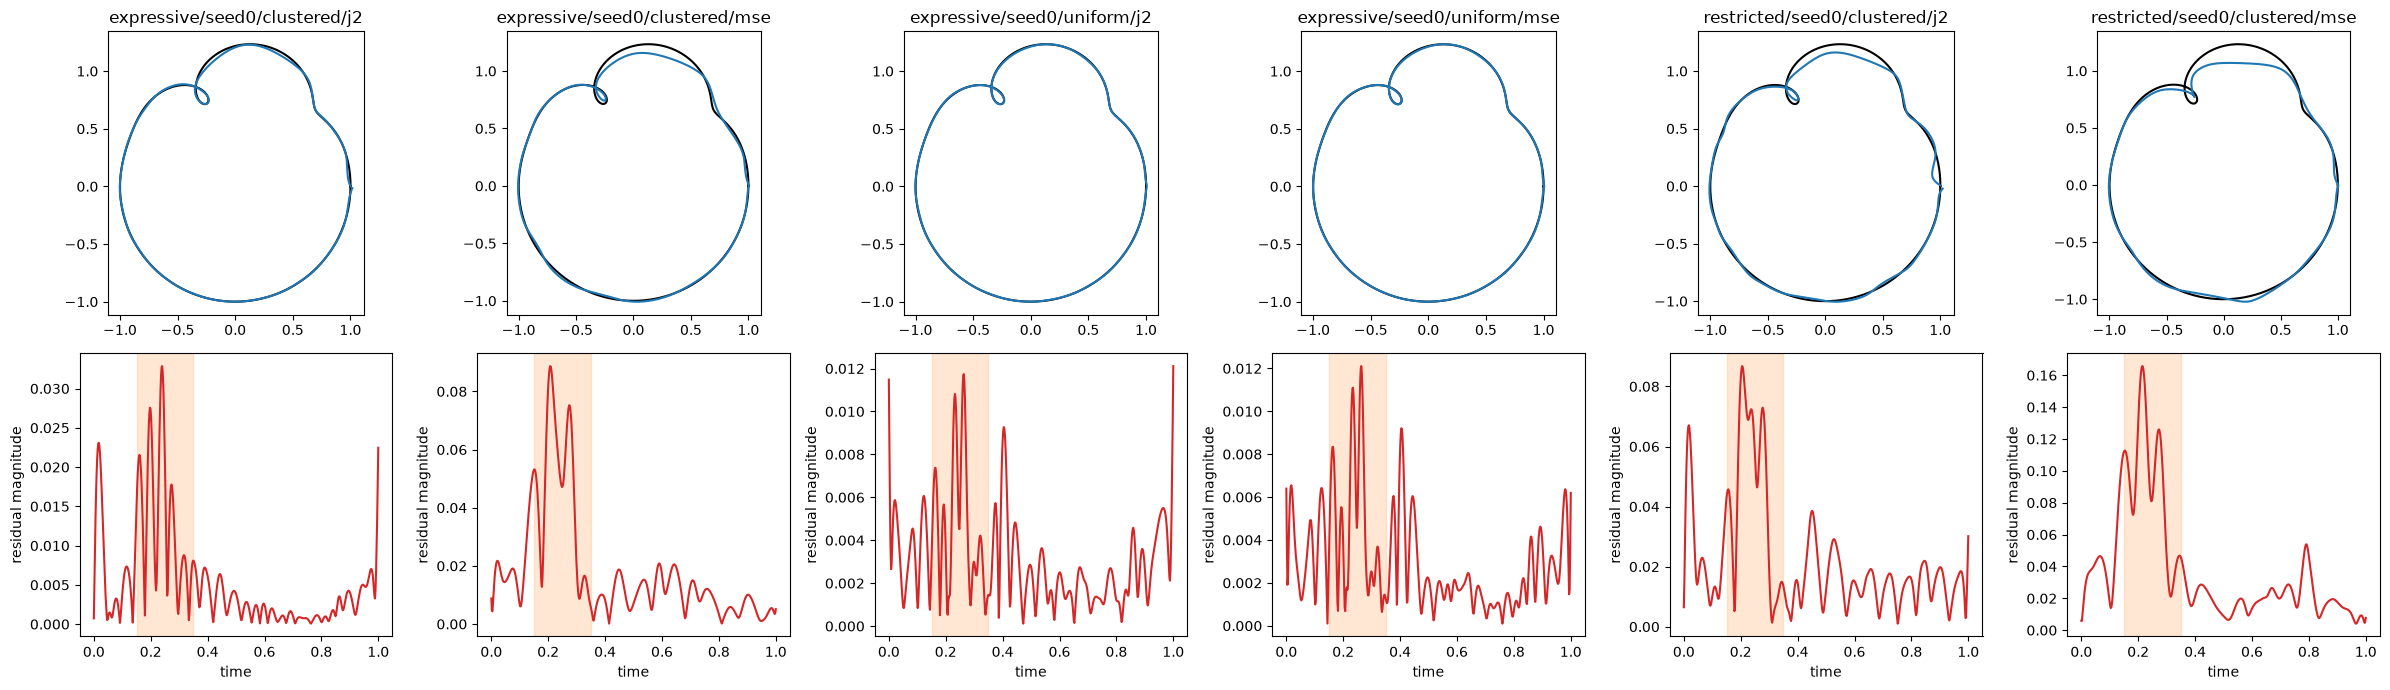

In [5]:
run_paths = sorted(RESULT_ROOT.glob('*/seed*/*/*/paths.npz'))
if run_paths:
    selected = run_paths[: min(6, len(run_paths))]
    figure, axes = plt.subplots(2, len(selected), figsize=(4 * len(selected), 7))
    axes = np.asarray(axes).reshape(2, len(selected))
    for column, path in enumerate(selected):
        arrays = np.load(path)
        label = '/'.join(path.parts[-5:-1])
        axes[0, column].plot(arrays['target'][:, 0], arrays['target'][:, 1], color='black')
        axes[0, column].plot(arrays['prediction'][:, 0], arrays['prediction'][:, 1])
        axes[0, column].set_title(label)
        axes[0, column].set_aspect('equal')
        residual = np.linalg.norm(arrays['prediction'] - arrays['target'], axis=-1)
        axes[1, column].plot(arrays['time'], residual, color='tab:red')
        axes[1, column].axvspan(0.15, 0.35, color='tab:orange', alpha=0.18)
        axes[1, column].set_xlabel('time')
        axes[1, column].set_ylabel('residual magnitude')
    figure.tight_layout()


### 8.3 Signature scaling audit

Before signature training, compare anchor and level contributions together with parameter-gradient norms. Audit diagnoses optimization geometry; it does not force equal gradients, which would define a different loss. Audit inspects unused seed 991 at initialization rather than comparative performance.

#### Result, 28 August

All recorded values and aggregate parameter-gradient norms are finite and nonzero. Global loss has large discrepancies at levels two to four, while gradient norm decreases strongly with depth. Local loss is initially dominated by anchor gradient; depth-two gradient is small but nonzero. This is accepted as a property to measure through checkpointed training rather than removed by post-hoc factorial or anchor reweighting.

Unit output scaling is frozen because time is normalized, target outputs are dimensionless and order one, and audit shows no overflow, nonfinite value or zero total gradient. Acceptance means both objectives are trainable enough for pilot; it does not assert balanced levels. Pilot checkpoint metrics determine whether structural terms become active after anchor error falls.


In [6]:
signature_audit_file = RESULT_ROOT / 'signature_audit/signature_audit.json'
if signature_audit_file.exists():
    signature_audit = json.loads(signature_audit_file.read_text())['audit']
    audit_rows = []
    for representation, specification in signature_audit['representations'].items():
        for component, values in specification['components'].items():
            audit_rows.append({
                'representation': representation,
                'depth': specification['depth'],
                'intervals': specification['intervals'],
                'feature_count': specification['feature_count'],
                'component': component,
                **values,
            })
    display(pd.DataFrame(audit_rows))
else:
    display(Markdown('Signature audit has not been run.'))


Signature audit has not been run.

## 9. Acceptance before interpretation

Loss comparison is interpretable only after confirming that model can represent target, paired runs begin identically, gradients reach every parameter and numerical approximations are stable. Required checks are:

1. Fourier adequacy file reports improvement over raw time and expressive dense MSE at most $10^{-3}$.
2. Initial fingerprints match across losses within every capacity and seed.
3. Every parameter receives finite gradient.
4. Training loss decreases, dense fitted paths are finite, and common checkpoint metrics are recorded.
5. Representative fitted paths and reported metrics are stable when reevaluated with RK4 step $1/1024$.
6. Before signature training, straight-line and concatenation checks validate signature coordinates; translation and anchor tests validate absolute-level handling; levelwise loss and gradient magnitudes are recorded.

Results and interpretation are added only after these checks pass.

Prediction fixed in advance: under uniform observations MSE and $J_2$ differ by two endpoint half-weights only, so their fits should agree closely. Separation is expected under clustered observations.


## 10. Fourier adequacy result, 23 August

This preliminary run tests model representation before comparing losses. Expressive model was trained once with raw time and once with Fourier time features. Capacity label, seed, observations, optimizer and update count match; Fourier model has additional input features and therefore more parameters. Comparison decides whether adopted representation is adequate rather than whether equal-size architectures differ.

Expressive model $(H=8,w=64)$ was trained under uniform-observation MSE for 5,000 updates using unused seed 991. Raw scalar time reached dense MSE $6.15\times10^{-3}$. Fourier time map reached $9.88\times10^{-6}$, below pre-fixed $10^{-3}$ threshold. Maximum pointwise error was $9.68\times10^{-3}$ and local-event $J_2$ was $2.39\times10^{-5}$.

Adequacy gate passes. Fourier features remain in experiment A. Expressive model provides intended near-exact-fit capacity control. This pilot compares time representation rather than path losses; seed 991 is excluded from comparative results.


raw_dense_mse              0.006149
fourier_dense_mse           0.00001
max_dense_mse                 0.001
fourier_improves               True
expressive_fit_adequate        True
passed                         True
Name: adequacy, dtype: object

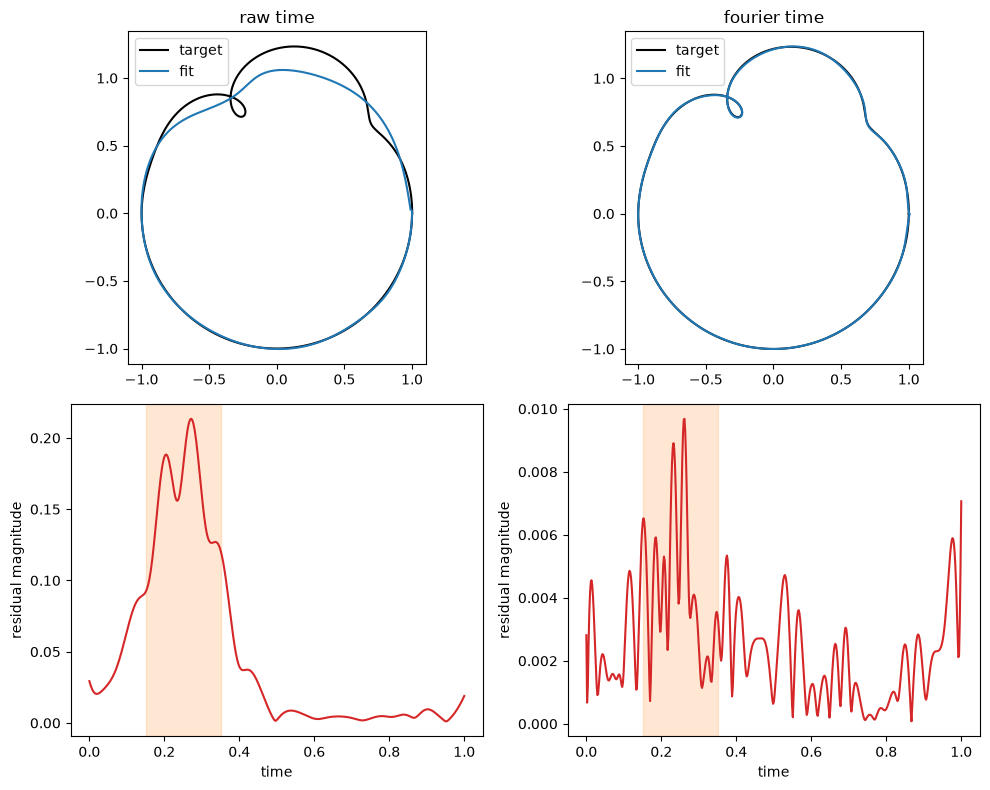

In [7]:
adequacy_root = RESULT_ROOT / 'adequacy'
adequacy_file = adequacy_root / 'adequacy.json'
if adequacy_file.exists():
    display(pd.Series(json.loads(adequacy_file.read_text()), name='adequacy'))
    figure, axes = plt.subplots(2, 2, figsize=(10, 8))
    for column, representation in enumerate(['raw_time', 'fourier_time']):
        arrays = np.load(adequacy_root / representation / 'paths.npz')
        axes[0, column].plot(arrays['target'][:, 0], arrays['target'][:, 1], color='black', label='target')
        axes[0, column].plot(arrays['prediction'][:, 0], arrays['prediction'][:, 1], label='fit')
        axes[0, column].set_title(representation.replace('_', ' '))
        axes[0, column].set_aspect('equal')
        axes[0, column].legend()
        residual = np.linalg.norm(arrays['prediction'] - arrays['target'], axis=-1)
        axes[1, column].plot(arrays['time'], residual, color='tab:red')
        axes[1, column].axvspan(0.15, 0.35, color='tab:orange', alpha=0.18)
        axes[1, column].set_xlabel('time')
        axes[1, column].set_ylabel('residual magnitude')
    figure.tight_layout()
else:
    display(Markdown('Adequacy output is absent.'))
